# Анализ пешеходной доступности зданий от остановок общественного транспорта (на примере Петроградского района Санкт-Петербурга)

## 1. Цель работы
Оценить долю жилых зданий в Петроградском районе, попадающих в 500-метровую пешеходную зону доступности от остановок общественного транспорта.  
Построить карту с выделением доступных и недоступных зданий.

## 2. Данные и методология
- **Исходные данные**: границы района, здания и остановки загружены из OpenStreetMap с помощью библиотеки OSMnx.
- **Метрическая проекция**: UTM зона 36N (EPSG:32636) для корректного расчёта расстояний.
- **Зона доступности**: буфер 500 м вокруг остановок.
- **Пространственное соединение**: определение зданий, пересекающихся с зоной доступности.
- **Визуализация**: карта с подложкой CartoDB Positron, цветовая дифференциация зданий.

## 3. Импорт библиотек и настройки

In [3]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import contextily as cx  
import os
from shapely.ops import unary_union
import warnings
warnings.filterwarnings("ignore")

In [4]:
# загрузка границ района
district = ox.geocode_to_gdf('Петроградский район, Санкт-Петербург, Россия')
polygon = district.geometry.union_all()

# загрузка зданий и остановок внутри района
buildings = ox.features_from_polygon(polygon, tags={'building': True})
stops = ox.features_from_polygon(polygon, tags={'public_transport': 'stop_position'})

print(f"Загружено зданий: {len(buildings)}")
print(f"Загружено остановок: {len(stops)}")

Загружено зданий: 3890
Загружено остановок: 196


## 5. Подготовка данных: проекция и буферы

In [5]:
# переводим всё в единую метрическую проекцию для расчётов
utm_crs = stops.estimate_utm_crs()
stops_utm = stops.to_crs(utm_crs)
buildings_utm = buildings.to_crs(utm_crs)
district_utm = district.to_crs(utm_crs)

# буферы вокруг остановок (500 м)
stops_buffer_utm = stops_utm.copy()
stops_buffer_utm.geometry = stops_buffer_utm.geometry.buffer(500)

# объединение зон доступности
united_zone = unary_union(stops_buffer_utm.geometry)
zone_gdf = gpd.GeoDataFrame(geometry=[united_zone], crs=utm_crs)

## 6. Пространственный анализ: какие здания попадают в зону

In [6]:
# пространственное соединение
buildings_in_zone = gpd.sjoin(buildings_utm, zone_gdf, how='inner', predicate='intersects')

total_buildings = len(buildings_utm)
accessible_buildings = len(buildings_in_zone)
percentage = (accessible_buildings / total_buildings) * 100

print(f"Всего зданий: {total_buildings}")
print(f"Зданий в зоне доступности: {accessible_buildings} ({percentage:.1f}%)")

Всего зданий: 3890
Зданий в зоне доступности: 3659 (94.1%)


## 7. Визуализация

Карта сохранена в ..\output\map_buildings_access.png


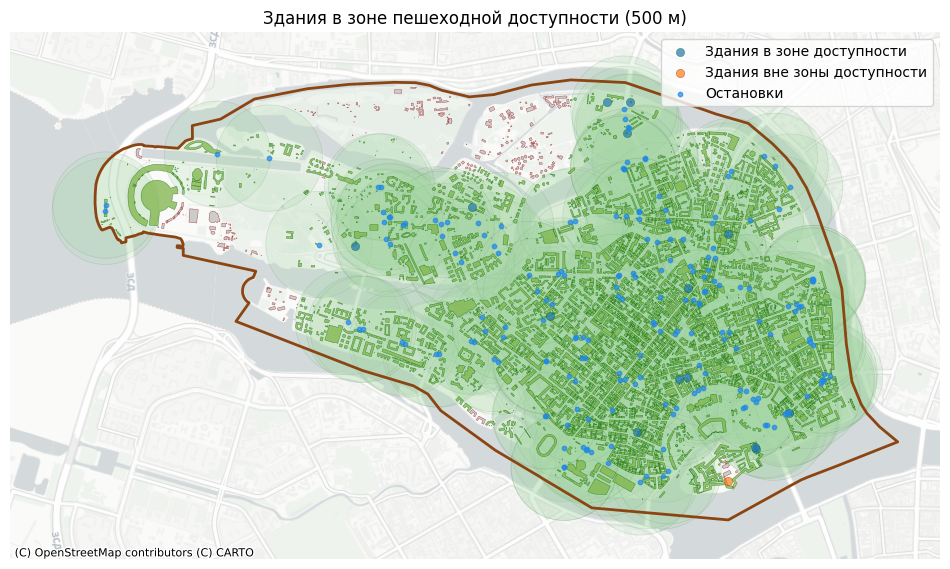

In [10]:
# переводим в EPSG:3857 для визуализации
stops_wm = stops_utm.to_crs(epsg=3857)
district_wm = district_utm.to_crs(epsg=3857)
stops_buffer_wm = stops_buffer_utm.to_crs(epsg=3857)
buildings_wm = buildings_utm.to_crs(epsg=3857)

# разделяем здания на две группы, создаем маску
in_zone_mask = buildings_wm.index.isin(buildings_in_zone.index)

if not buildings_in_zone.empty:
    buildings_in_zone_wm = buildings_wm.loc[in_zone_mask]
else:
    buildings_in_zone_wm = gpd.GeoDataFrame()

buildings_out_zone_wm = buildings_wm[~in_zone_mask]

# визуализация
fig, ax = plt.subplots(figsize=(12, 12))

# буферы и границы
stops_buffer_wm.plot(ax=ax, color='#A5D6A5', alpha=0.2, label='Зона 500 м', edgecolor='#558B55', linewidth=0.5)
district_wm.plot(ax=ax, color='none', edgecolor='#8B4513', linewidth=2, label='Район')

# здания
if not buildings_in_zone_wm.empty:
    buildings_in_zone_wm.plot(ax=ax, facecolor='#7CB342', edgecolor='darkgreen',
                              linewidth=0.3, alpha=0.7, label='Здания в зоне доступности')
if not buildings_out_zone_wm.empty:
    buildings_out_zone_wm.plot(ax=ax, facecolor='#BDBDBD', edgecolor='darkred',
                               linewidth=0.3, alpha=0.7, label='Здания вне зоны доступности')

# остановки
stops_wm.plot(ax=ax, color='#1E88E5', markersize=10, alpha=0.7, label='Остановки')

# подложка 
cx.add_basemap(ax, crs=stops_wm.crs.to_string(), source=cx.providers.CartoDB.Positron)

ax.legend()
ax.set_title('Здания в зоне пешеходной доступности (500 м)')
ax.set_axis_off()

# сохранение в файл
output_dir = "..\output"
os.makedirs(output_dir, exist_ok=True)
filepath = os.path.join(output_dir, 'map_buildings_access.png')
plt.savefig(filepath, dpi=300, bbox_inches='tight')
print(f"Карта сохранена в {filepath}")

plt.show()




## 8. Сохранение результатов в GeoPackage

In [8]:
buildings_utm['in_zone'] = buildings_utm.index.isin(buildings_in_zone.index)

output_path = '../output/buildings_petrogradsky.gpkg'
buildings_utm.to_file(output_path, driver='GPKG')
print(f"Сохранено в {output_path}")
stops_utm.to_file('../output/stops_petrogradsky.gpkg', driver='GPKG')
stops_buffer_utm.to_file('../output/buffers_petrogradsky.gpkg', driver='GPKG')

Сохранено в ../output/buildings_petrogradsky.gpkg


## 9. Выводы
- В Петроградском районе 94.1% жилых зданий находятся в 500-метровой пешеходной доступности от остановок общественного транспорта.
- Это свидетельствует о высокой транспортной доступности, что характерно для центральных районов Санкт-Петербурга.
- Созданная карта и пространственные данные могут быть использованы для планирования маршрутов общественного транспорта или размещения новых остановок.
- Предложенный метод легко масштабируется на другие районы и типы инфраструктуры (школы, поликлиники, магазины).

In [9]:
print(f"\n=== Итоговая статистика ===")
print(f"Всего зданий: {total_buildings}")
print(f"Зданий в зоне доступности: {accessible_buildings}")
print(f"Процент доступных: {percentage:.1f}%")


=== Итоговая статистика ===
Всего зданий: 3890
Зданий в зоне доступности: 3659
Процент доступных: 94.1%
